In [3]:
import torch 
import pandas as pd 
import numpy as np
import os
from lincs_gsnn.data.DXDTDataset import DXDTDataset
from torch.utils.data import DataLoader 

from matplotlib import pyplot as plt
from sklearn.metrics import r2_score
from lincs_gsnn.models.ODEFunc import ODEFunc
from lincs_gsnn.data.TrajDataset import TrajDataset
from lincs_gsnn.data.DXDTDataset import DXDTDataset
from torchdiffeq import odeint 

from gsnn.interpret.GSNNExplainer import GSNNExplainer
from gsnn.interpret.IGExplainer import IGExplainer
from gsnn.interpret.ContrastiveIGExplainer import ContrastiveIGExplainer
from gsnn.interpret.NoiseTunnel import NoiseTunnel
from gsnn.interpret.ContrastiveOcclusionExplainer import ContrastiveOcclusionExplainer
from gsnn.interpret.OcclusionExplainer import OcclusionExplainer
from gsnn.interpret.utils import plot_edge_importance, plot_node_importance
from gsnn.interpret.CounterfactualExplainer import CounterfactualExplainer
from gsnn.interpret.ContrastiveGSNNExplainer import ContrastiveGSNNExplainer

from gsnn.interpret.utils import plot_edge_importance, plot_node_importance

import networkx as nx

import gseapy as gp

%load_ext autoreload
%autoreload 2


/home/teddy/miniconda3/envs/lincs-gsnn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
root_gsnn = '/home/teddy/local/workflow_outputs/lincs-gsnn/default'
root_traj = '/home/teddy/local/workflow_outputs/lincs-traj/runs/exp/default_v02/output/'

data = torch.load(os.path.join(root_gsnn, 'bionetwork/bionetwork.pt'), weights_only=False)
model = torch.load(os.path.join(root_gsnn, 'pretrain/pretrained_model.pt'), weights_only=False)
dxdt_scale = torch.load(os.path.join(root_gsnn, 'pretrain/dxdt_scale.pt'), weights_only=False).item()
x_names = pd.read_csv(os.path.join(root_traj, 'predict_grid/gene_names.csv'))['gene_names'].values.astype(str).tolist()
dxdt_meta = pd.read_csv(f'/home/teddy/local/workflow_outputs/lincs-traj/sample_0_from_arc/dxdt_meta.csv')

In [5]:
# freeze the model 
for param in model.parameters():
    param.requires_grad = False
model = model.eval() 

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [6]:
dxdt_meta.cell_iname.unique()

array(['HME1', 'BT20', 'BT474', 'HS578T', 'MCF10A', 'MCF7', 'MDAMB231',
       'MDAMB468', 'SKBR3', 'T47D', 'ZR751'], dtype=object)

In [7]:
# MDA-MB-231

In [8]:
dxdt_meta.pert_id.unique()

array(['BRD-K49328571', 'BRD-K51544265', 'BRD-K92723993', 'BRD-K81528515',
       'BRD-K99964838', 'BRD-K44227013', 'BRD-K33379087', 'BRD-K42828737',
       'BRD-K54997624', 'BRD-K12343256', 'BRD-K19687926', 'BRD-M07438658',
       'BRD-K51313569'], dtype=object)

In [9]:
def infer_trajectory(x0, model, data, dxdt_scale, t=None, method='dopri5', tol=1e-4):
    """
    Infer trajectory from initial state x0 using the model and odeint.
    
    Args:
        x0: Initial state tensor of shape (B, n_input_nodes) or (n_input_nodes,)
        model: The trained GSNN model
        data: Data object containing node_names_dict
        dxdt_scale: Scaling factor for dxdt predictions
        t: Time points tensor. If None, defaults to torch.linspace(0, 1, 100)
        method: ODE solver method (default: 'dopri5')
        tol: Tolerance for ODE solver (default: 1e-4)
    
    Returns:
        trajectory: Tensor of shape (n_time, B, n_genes) containing gene expression over time
    """
    # Ensure x0 is 2D (B, n_input_nodes)
    if x0.dim() == 1:
        x0 = x0.unsqueeze(0)
    
    # Default time points
    if t is None:
        t = torch.linspace(0, 1, 100).to(x0.device)
    
    # Create ODE function wrapper
    ode_func = ODEFunc(model, data.node_names_dict['input'], scale=dxdt_scale)
    
    # Integrate trajectory
    trajectory = ode_func.integrate(x0, t, method=method, tol=tol).squeeze(1)
    
    return trajectory, t


In [10]:
# Given a condition (set of dxdt obs within a condition), what edges are necessary to maintain the predicted values?


# https://www.nature.com/articles/cddis2017294 
drug1 = 'BRD-K92723993' # imatinib 
cell1 = 'MDAMB231' # MCF7
dose1 = 10.0

drug2 = 'BRD-K92723993' # imatinib 
cell2 = 'MCF7' #'MDAMB231' # MCF7
dose2 = 10.0



cond1 = dxdt_meta[(dxdt_meta['pert_id'] == drug1) 
                    & (dxdt_meta['cell_iname'] == cell1) 
                    & (dxdt_meta['dose'] == dose1)].reset_index(drop=True)

cond2 = dxdt_meta[(dxdt_meta['pert_id'] == drug2) 
                    & (dxdt_meta['cell_iname'] == cell2) 
                    & (dxdt_meta['dose'] == dose2)].reset_index(drop=True)
                    

In [11]:
target_ix = data.node_names_dict['output'].index('GENE__TP53')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [12]:
dataset1 = DXDTDataset(meta=cond1, 
                      input_names=data.node_names_dict['input'], 
                      output_names=data.node_names_dict['output'],
                      src_names=x_names,
                      obs_dir='/home/teddy/local/workflow_outputs/lincs-traj/sample_0_from_arc/obs/',
                      dxdt_dir='/home/teddy/local/workflow_outputs/lincs-traj/sample_0_from_arc/dxdt/',
                      scale=dxdt_scale)

dataloader1 = DataLoader(dataset1, batch_size=8, shuffle=False)

In [13]:
dataset2 = DXDTDataset(meta=cond2, 
                      input_names=data.node_names_dict['input'], 
                      output_names=data.node_names_dict['output'],
                      src_names=x_names,
                      obs_dir='/home/teddy/local/workflow_outputs/lincs-traj/sample_0_from_arc/obs/',
                      dxdt_dir='/home/teddy/local/workflow_outputs/lincs-traj/sample_0_from_arc/dxdt/',
                      scale=dxdt_scale)

dataloader2 = DataLoader(dataset2, batch_size=8, shuffle=False)

In [14]:
def retrieve_data(dataloader):

    xs = []; ys = [] 
    for i, (x, y) in enumerate(dataloader):
        xs.append(x)
        ys.append(y)
    xs = torch.cat(xs, dim=0)
    ys = torch.cat(ys, dim=0)

    return xs, ys 

x1, y1 = retrieve_data(dataloader1)
x2, y2 = retrieve_data(dataloader2)

In [74]:
t = torch.linspace(0, 72, 50, device=device)
tol = 1e-4

# GENES ONLY (NO drug or cell line inputs)
x1hat,_ = infer_trajectory(x1[0].to(device), 
                           model, 
                           data, 
                           dxdt_scale, 
                           t=t,
                           tol=tol) 

x2hat,_ = infer_trajectory(x2[0].to(device), 
                           model, 
                           data, 
                           dxdt_scale, 
                           t=t,
                           tol=tol)


xx1hat_with_inputs = x1.clone() 
xx1hat_with_inputs[:, :978] = x1hat

xx2hat_with_inputs = x2.clone() 
xx2hat_with_inputs[:, :978] = x2hat


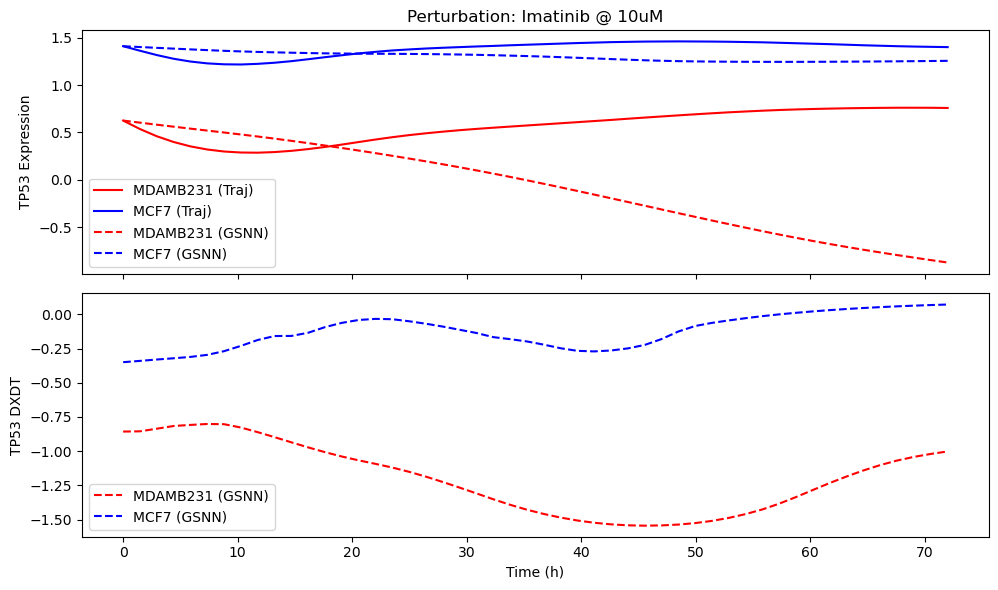

In [87]:
f, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(np.linspace(0, 72, x1.shape[0]), x1[:,757].detach().cpu().numpy(), 'r', label='MDAMB231 (Traj)')
axes[0].plot(np.linspace(0, 72, x2.shape[0]), x2[:,757].detach().cpu().numpy(), 'b', label='MCF7 (Traj)')
axes[0].plot(np.linspace(0, 72, x1hat.shape[0]), x1hat[:,757].detach().cpu().numpy(), 'r--', label='MDAMB231 (GSNN)')
axes[0].plot(np.linspace(0, 72, x2hat.shape[0]), x2hat[:,757].detach().cpu().numpy(), 'b--', label='MCF7 (GSNN)')
axes[0].set_ylabel('TP53 Expression')
axes[0].set_title('Perturbation: Imatinib @ 10uM')
axes[0].legend()

dxdt1 = model(xx1hat_with_inputs.to(device))[:, target_ix].detach().cpu().numpy()
dxdt2 = model(xx2hat_with_inputs.to(device))[:, target_ix].detach().cpu().numpy()

axes[1].plot(np.linspace(0, 72, x1hat.shape[0]), dxdt1, 'r--', label='MDAMB231 (GSNN)')
axes[1].plot(np.linspace(0, 72, x2hat.shape[0]), dxdt2, 'b--', label='MCF7 (GSNN)')
axes[1].set_xlabel('Time (h)')
axes[1].set_ylabel('TP53 DXDT')
axes[1].legend()
plt.tight_layout()
plt.show()

In [88]:
xx1hat_with_inputs = x1.clone() 
xx1hat_with_inputs[:, :978] = x1hat

xx2hat_with_inputs = x2.clone() 
xx2hat_with_inputs[:, :978] = x2hat

In [18]:
explainer = ContrastiveGSNNExplainer(model.to(device), 
                                     data,
                                     hard=False,
                                     beta=1e-2,
                                     lr=1e-1,
                                     prior=5,
                                     iters=500,
                                     free_edges=100)
                                     
cres_gsnn = explainer.explain(xx1hat_with_inputs.to(device), 
                              xx2hat_with_inputs.to(device), 
                              target_idx=target_ix, 
                              target='edge')

cres_gsnn.head()

Batch size: 50, Target dims: 1
Target Δf mean: -1.070862, std: 0.299739
iter: 499 | loss: 7.1283 | mse: 0.0319 | r2: 0.638 | active edges: 789 / 19909 | entropy: 0.01619896
POST-TRAINING EVALUATION (edges > 0.5)
Selected edges: 741 / 19909 (3.7%)
Target Δf mean: -1.070862
Subset Δf mean: -1.048456
MSE: 0.030422
R² (across 50x1 elements): 0.6545


,source,target,score
0,PROTEIN__DAPK3,PROTEIN__DAPK1,0.001681
1,PROTEIN__DAPK3,PROTEIN__NR3C1,0.003763
2,PROTEIN__DAPK3,PROTEIN__AR,0.001591
3,PROTEIN__DAPK3,PROTEIN__TP53,0.000333
4,PROTEIN__DAPK3,PROTEIN__STAT3,0.000714


In [19]:
explainer = ContrastiveIGExplainer(model.to(device), data, n_steps=100)
cres_ig = explainer.explain(xx1hat_with_inputs.to(device), 
                        xx2hat_with_inputs.to(device), 
                        target_idx=target_ix, 
                        target='edge')

cres_ig.head()

,source,target,score
0,PROTEIN__DAPK3,PROTEIN__DAPK1,-0.033345
1,PROTEIN__DAPK3,PROTEIN__NR3C1,0.286538
2,PROTEIN__DAPK3,PROTEIN__AR,-0.025875
3,PROTEIN__DAPK3,PROTEIN__TP53,-0.016404
4,PROTEIN__DAPK3,PROTEIN__STAT3,-0.006435


In [20]:
explainer = ContrastiveOcclusionExplainer(model.to(device), data)
cres_occ = explainer.explain(xx1hat_with_inputs.to(device), 
                            xx2hat_with_inputs.to(device), 
                            target_idx=target_ix, 
                            element_mask=cres_gsnn.score.values > 0.5,
                            target='edge')

cres_occ.head()

,source,target,score
0,PROTEIN__DAPK3,PROTEIN__DAPK1,NaN
1,PROTEIN__DAPK3,PROTEIN__NR3C1,NaN
2,PROTEIN__DAPK3,PROTEIN__AR,NaN
3,PROTEIN__DAPK3,PROTEIN__TP53,NaN
4,PROTEIN__DAPK3,PROTEIN__STAT3,NaN


In [21]:
cres = cres_ig.merge(cres_gsnn, on=['source', 'target'], how='inner').rename(columns={'score_x': 'ig_score', 'score_y': 'gsnn_score'})
cres = cres.merge(cres_occ, on=['source', 'target'], how='left').rename(columns={'score': 'occ_score'})
cres = cres.assign(score = lambda x: x.occ_score)
cres.head() 

,source,target,ig_score,gsnn_score,occ_score,score
0,PROTEIN__DAPK3,PROTEIN__DAPK1,-0.033345,0.001681,NaN,NaN
1,PROTEIN__DAPK3,PROTEIN__NR3C1,0.286538,0.003763,NaN,NaN
2,PROTEIN__DAPK3,PROTEIN__AR,-0.025875,0.001591,NaN,NaN
3,PROTEIN__DAPK3,PROTEIN__TP53,-0.016404,0.000333,NaN,NaN
4,PROTEIN__DAPK3,PROTEIN__STAT3,-0.006435,0.000714,NaN,NaN


In [22]:
cres[['ig_score', 'occ_score', 'gsnn_score']].corr()

,ig_score,occ_score,gsnn_score
ig_score,1.000000,-0.067197,0.021324
occ_score,-0.067197,1.000000,0.008225
gsnn_score,0.021324,0.008225,1.000000


In [24]:
cres.sort_values(by='occ_score', ascending=False).head(10)

,source,target,ig_score,gsnn_score,occ_score,score
17799,RNA__TP53,GENE__TP53,0.715433,0.999985,1.070862,1.070862
6773,GENE__ABL1,RNA__ABL1,-1.116719,0.999996,0.795823,0.795823
13729,LINE__MDAMB231,RNA__TP53,0.130857,0.999987,0.721722,0.721722
6716,GENE__SYK,RNA__SYK,9.350348,0.999459,0.702294,0.702294
6445,GENE__STAT1,RNA__STAT1,0.637447,0.999978,0.671792,0.671792
7127,DRUG__BRD-K92723993,PROTEIN__ABL2,-20.645855,0.999994,0.651632,0.651632
6968,GENE__TP53,RNA__TP53,0.254197,0.999980,0.522929,0.522929
18856,RNA__TP53,RNA__TP53,0.296905,0.999939,0.515250,0.515250
7035,GENE__CREB1,RNA__CREB1,-0.395878,0.999625,0.498276,0.498276
13352,LINE__MDAMB231,RNA__E2F2,0.062466,0.999508,0.477802,0.477802


In [38]:
cres[lambda x: x.source.isin(['LINE__MDAMB231', 'LINE__MCF7'])].sort_values(by='occ_score', ascending=False).dropna().head(5)

,source,target,ig_score,gsnn_score,occ_score,score
13729,LINE__MDAMB231,RNA__TP53,0.130857,0.999987,0.721722,0.721722
13352,LINE__MDAMB231,RNA__E2F2,0.062466,0.999508,0.477802,0.477802
13074,LINE__MDAMB231,PROTEIN__PAX2,0.209101,0.999663,0.288117,0.288117
12901,LINE__MDAMB231,PROTEIN__CREB1,-0.239089,0.999989,0.234008,0.234008
13389,LINE__MDAMB231,RNA__FOS,0.110369,0.999849,0.211514,0.211514


In [35]:
cres2 = cres[lambda x: (x.gsnn_score > 0.5)]# & (x.occ_score.abs() > 0.1)]
cres2.shape

(741, 6)

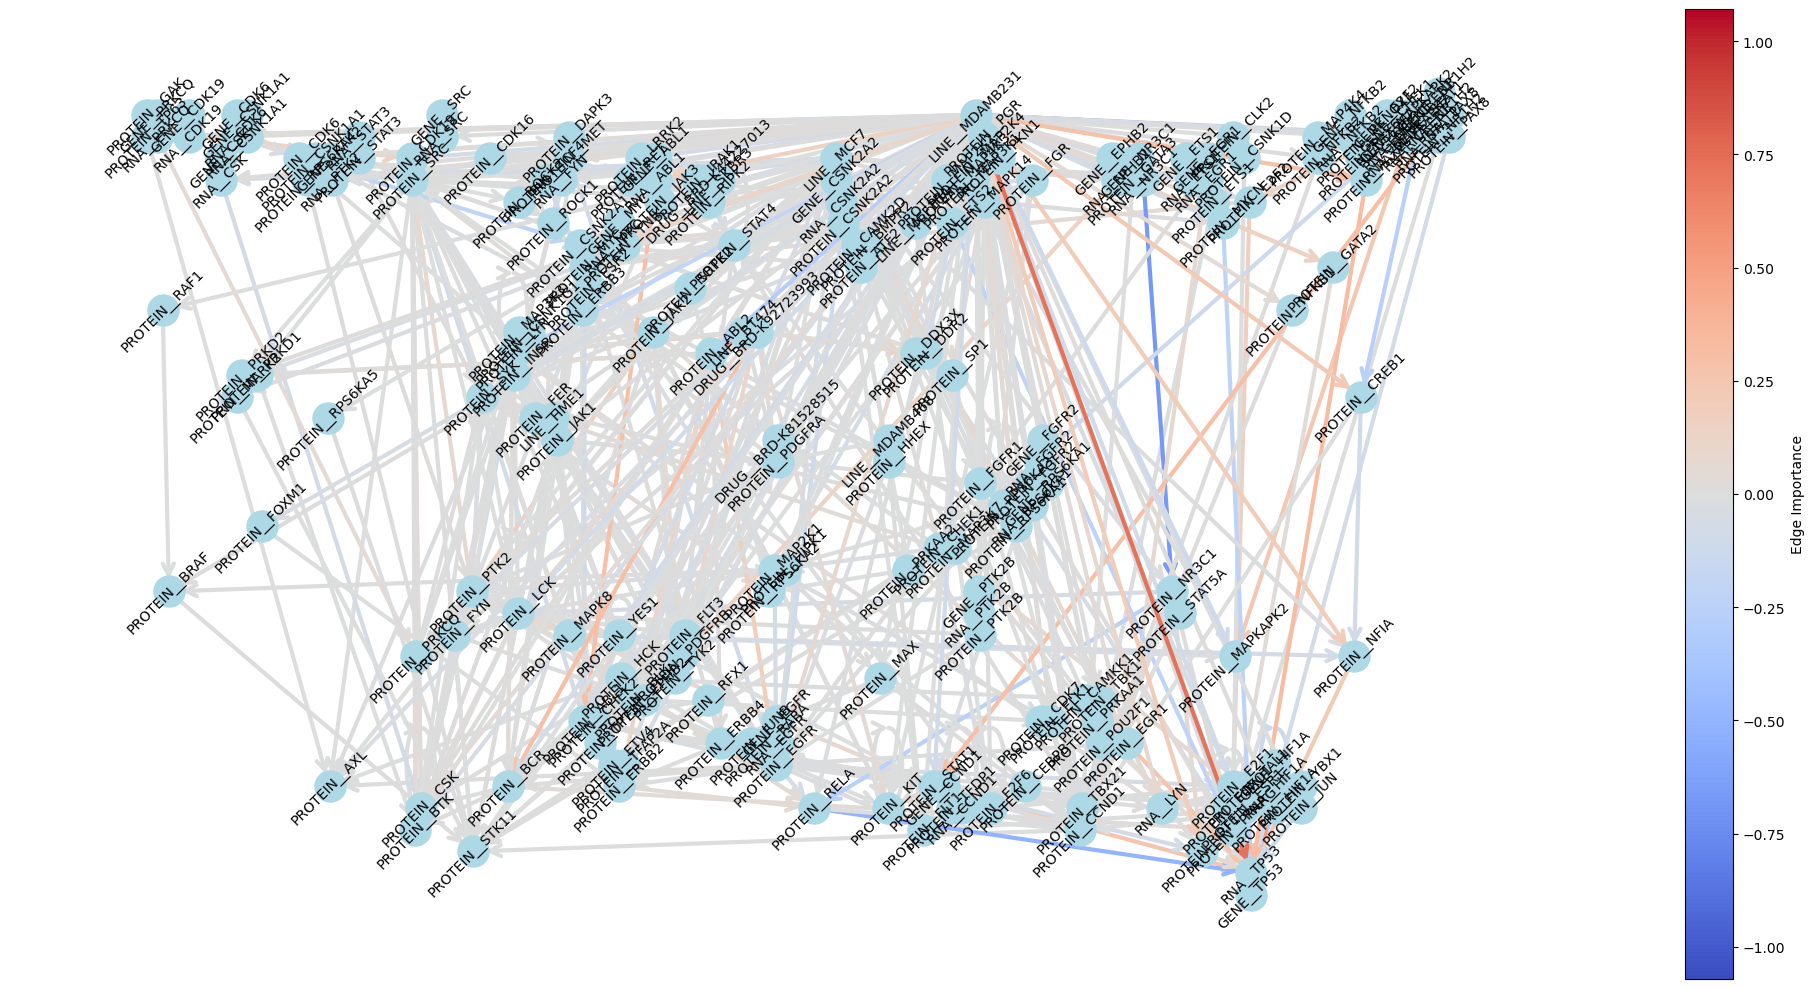

In [37]:
plot_edge_importance(cres2, figsize=(20,10), leafs=['GENE__TP53'])

In [39]:
cres2.shape

(741, 6)

In [65]:
G = nx.from_pandas_edgelist(cres2.assign(abs_score=lambda x: x.occ_score.abs()), source='source', target='target', edge_attr='abs_score', create_using=nx.DiGraph)


In [70]:
# community detection
coms = nx.community.louvain_communities(G, resolution=1.)

print('# of communities:', len(coms))
print('sizes of communities:', [len(c) for c in coms])
# MDBMBA 213  only (not contrastive)

node2com = {n: i for i, com in enumerate(coms) for n in com}

# of communities: 12
sizes of communities: [26, 41, 20, 11, 28, 3, 11, 65, 22, 22, 2, 24]


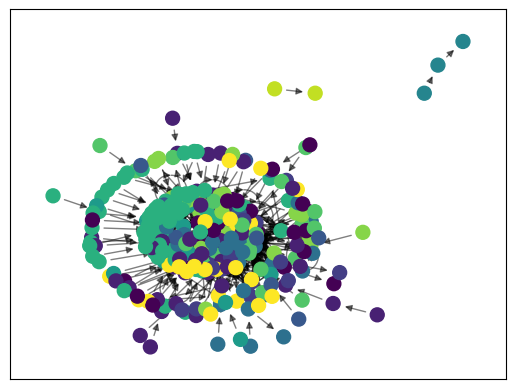

In [71]:
# color by community
colors = [node2com[node] for node in G.nodes()]
pos = nx.nx_pydot.pydot_layout(G)

plt.figure()
nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=100)
nx.draw_networkx_edges(G, pos, width=1, alpha=0.5)
plt.show()


In [72]:
background = [x.split('__')[1] for x in G.nodes()]

for i, com in enumerate(coms): 

    if len(com) < 10: 
        continue

    print('-'*100)
    print(f'Community {i+1} size: {len(com)}')

    com = [x.split('__')[1] for x in com]

    enr = gp.enrichr(com, 'GO_Biological_Process_2021', background=background, outdir=None)

    print(enr.res2d[lambda x: x['Adjusted P-value'] < 0.05].sort_values(by='Adjusted P-value', ascending=True).head(5)[['Term', 'Adjusted P-value']])

    print('-'*100)

----------------------------------------------------------------------------------------------------
Community 1 size: 26
Empty DataFrame
Columns: [Term, Adjusted P-value]
Index: []
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
Community 2 size: 41
                                                Term  Adjusted P-value
0  regulation of transcription by RNA polymerase ...          0.000031
1  negative regulation of transcription, DNA-temp...          0.000149
2  negative regulation of transcription by RNA po...          0.000154
3  positive regulation of transcription, DNA-temp...          0.000252
4  positive regulation of nucleic acid-templated ...          0.000652
----------------------------------------------------------------------------------------------------
--------------------------------------------------------------------

# MDBMBA 213  only (not contrastive)

In [176]:
explainer = GSNNExplainer(model.to(device), data, 
                          hard=False, 
                          beta=1e-2, 
                          lr=1e-1, 
                          prior=5, 
                          iters=1000, 
                          free_edges=100)



gsnn_res1 = explainer.explain(xx1hat_with_inputs.to(device), target_idx=[757], target='edge')

iter: 999 | loss: 4.0467 | mse: 0.0154 | r2: 0.758 | active edges: 473 / 19909 | entropy: 0.01596215
POST-TRAINING EVALUATION (edges > 0.5)
Selected edges: 443 / 19909 (2.2%)
MSE (subset): 0.019003
R² (subset): 0.7024
Variance explained: 0.7678
Correlation: 0.8762


In [177]:
explainer = OcclusionExplainer(model.to(device), data)
occlusion_res1 = explainer.explain(xx1hat_with_inputs.to(device), 
                                   target_idx=757, 
                                   target='edge', 
                                   element_mask=gsnn_res1.score.values > 0.5) 

In [178]:
explainer = IGExplainer(model.to(device), data)
ig_res1 = explainer.explain(xx1hat_with_inputs.to(device), target_idx=target_ix, target='edge', reduction='sum')

In [179]:
res1 = gsnn_res1.merge(ig_res1, on=['source', 'target'], how='inner').rename(columns={'score_x': 'gsnn_score', 'score_y': 'ig_score'})
res1 = res1.merge(occlusion_res1, on=['source', 'target'], how='left').rename(columns={'score': 'occlusion_score'})
res1 = res1.assign(score = lambda x: x.occlusion_score)
res1 = res1[lambda x: x.gsnn_score > 0.5]
res1 = res1[lambda x: x.occlusion_score.abs() > 0.1]
print(res1.shape)
res1.head()

(51, 6)


,source,target,gsnn_score,ig_score,occlusion_score,score
472,PROTEIN__E2F1,RNA__TP53,0.996113,-11.825714,-0.274647,-0.274647
684,PROTEIN__HIF1A,RNA__TP53,0.995061,2.415000,0.203412,0.203412
1206,RNA__NR3C1,PROTEIN__NR3C1,0.529879,153.787369,0.521190,0.521190
1581,PROTEIN__ABL2,PROTEIN__EGFR,0.999953,-66.217514,-0.191818,-0.191818
2272,PROTEIN__MAP2K1,PROTEIN__FOS,0.998328,-6.704461,0.152204,0.152204


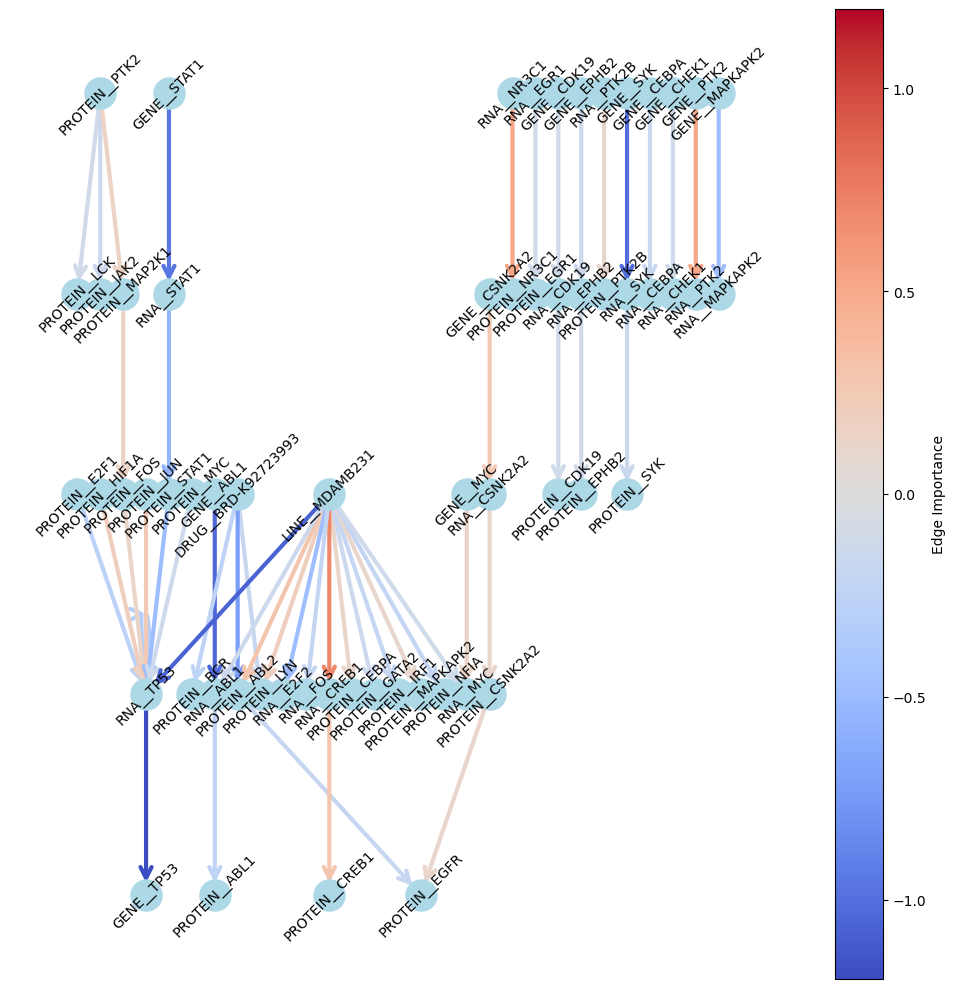

In [180]:
plot_edge_importance(res1, figsize=(10,10))#, leafs=['GENE__TP53'])
#plot_node_importance(res2, leafs=target_name, figsize=(10,10))

In [ ]:
# MDAMB231 has mutation in TP53 and overexpression of PAX5 

# MCF7 

In [181]:
explainer = GSNNExplainer(model.to(device), data, 
                          hard=False, 
                          beta=1e-2, 
                          lr=1e-1, 
                          prior=5, 
                          iters=1000, 
                          free_edges=100)



gsnn_res2 = explainer.explain(xx2hat_with_inputs.to(device), target_idx=[757], target='edge')

iter: 999 | loss: 0.7213 | mse: 0.0311 | r2: -0.976 | active edges: 140 / 19909 | entropy: 0.0154243
POST-TRAINING EVALUATION (edges > 0.5)
Selected edges: 91 / 19909 (0.5%)
MSE (subset): 0.031117
R² (subset): -0.9757
Variance explained: 0.0000
Correlation: nan


/home/teddy/miniconda3/envs/lincs-gsnn/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/teddy/miniconda3/envs/lincs-gsnn/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [182]:
explainer = OcclusionExplainer(model.to(device), data)
occlusion_res2 = explainer.explain(xx2hat_with_inputs.to(device), 
                                   target_idx=757, 
                                   target='edge', 
                                   element_mask=gsnn_res2.score.values > 0.5) 

In [183]:
explainer = IGExplainer(model.to(device), data)
ig_res2 = explainer.explain(xx2hat_with_inputs.to(device), target_idx=target_ix, target='edge', reduction='sum')

In [184]:
res2 = gsnn_res2.merge(ig_res2, on=['source', 'target'], how='inner').rename(columns={'score_x': 'gsnn_score', 'score_y': 'ig_score'})
res2 = res2.merge(occlusion_res2, on=['source', 'target'], how='left').rename(columns={'score': 'occlusion_score'})
res2 = res2.assign(score = lambda x: x.occlusion_score)
res2 = res2[lambda x: x.gsnn_score > 0.5]
res2 = res2[lambda x: x.occlusion_score.abs() > 0.0]
print(res2.shape)
res2.head()

(91, 6)


,source,target,gsnn_score,ig_score,occlusion_score,score
122,PROTEIN__POU2F1,PROTEIN__CCND1,0.999042,-201.729187,0.000280,0.000280
166,PROTEIN__JAK3,PROTEIN__JAK1,0.999878,385.069336,-0.001594,-0.001594
408,PROTEIN__ABL1,PROTEIN__JAK1,0.999977,-238.692902,0.005669,0.005669
417,PROTEIN__BCR,PROTEIN__JAK2,0.999901,589.258484,-0.004449,-0.004449
587,PROTEIN__EPHB2,PROTEIN__STK11,0.998874,275.053986,0.002460,0.002460


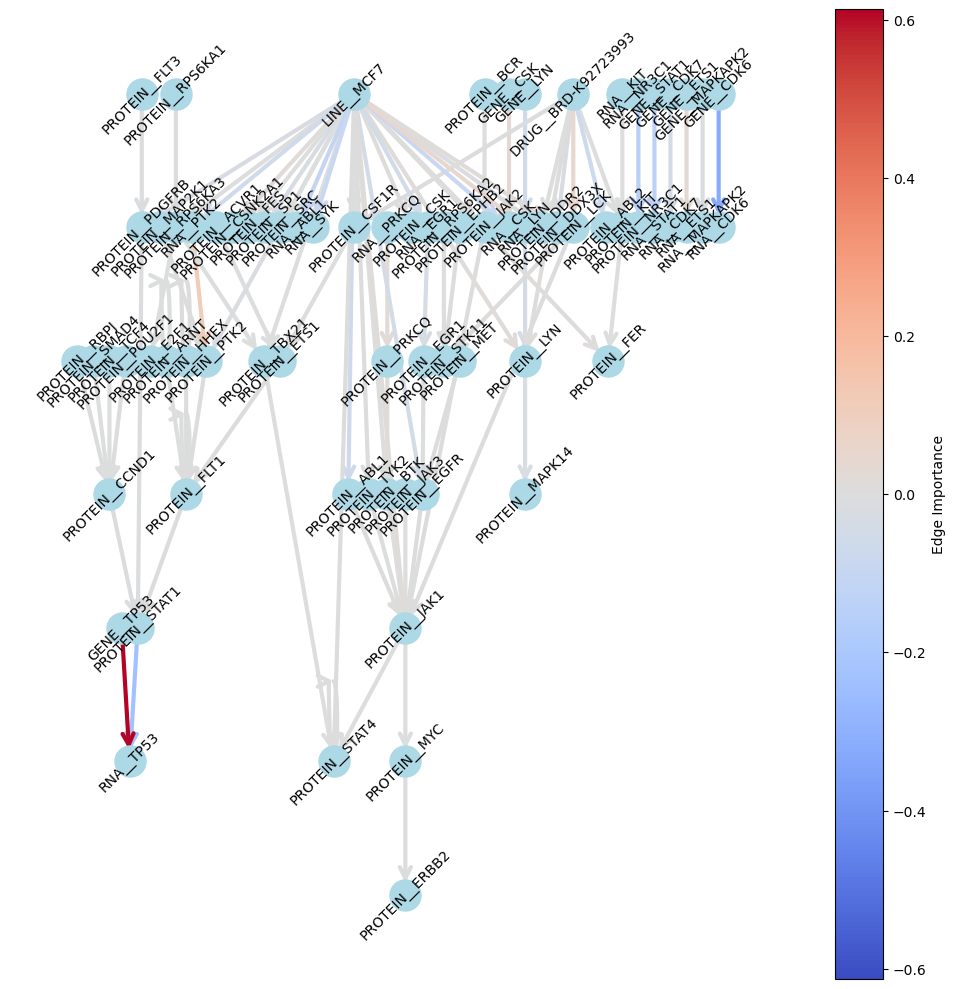

In [185]:
plot_edge_importance(res2, figsize=(10,10))